# Customer Segmentation — Wholesale Distributor
**Author:** Ali Omar Abdi

Reproduces the Lesson 6 K-Means pipeline (`code/customer-segmentation.py`) and adds a second clustering algorithm (Agglomerative / Hierarchical Clustering) for comparison, per Assignment Six, Part B.


## STEP 0 — Import the libraries

In [6]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

CSV_PATH = "raw_wholesale_customers.csv"
OUT_PATH = "segmented_wholesale_customers.csv"
FEATURES = ["Fresh", "Milk", "Grocery", "Frozen", "Detergents_Paper", "Delicassen"]
RANDOM_STATE = 42
K = 5


## STEP 2 — Load Dataset

In [7]:
df = pd.read_csv(CSV_PATH)
print("=== INITIAL SNAPSHOT ===")
print(df.head())
print()
df.info()

=== INITIAL SNAPSHOT ===
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null 

## STEP 2 — Select Features + IQR Cap

In [8]:
X = df[FEATURES].copy()

def iqr_fun(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return lower, upper

low_fresh,    high_fresh    = iqr_fun(X["Fresh"])
low_milk,     high_milk     = iqr_fun(X["Milk"])
low_grocery,  high_grocery  = iqr_fun(X["Grocery"])
low_frozen,   high_frozen   = iqr_fun(X["Frozen"])
low_det,      high_det      = iqr_fun(X["Detergents_Paper"])
low_deli,     high_deli     = iqr_fun(X["Delicassen"])

X["Fresh"]            = X["Fresh"].clip(lower=low_fresh,    upper=high_fresh)
X["Milk"]             = X["Milk"].clip(lower=low_milk,      upper=high_milk)
X["Grocery"]          = X["Grocery"].clip(lower=low_grocery, upper=high_grocery)
X["Frozen"]            = X["Frozen"].clip(lower=low_frozen,  upper=high_frozen)
X["Detergents_Paper"] = X["Detergents_Paper"].clip(lower=low_det,  upper=high_det)
X["Delicassen"]       = X["Delicassen"].clip(lower=low_deli,  upper=high_deli)

df[FEATURES] = X

print("=== IQR CAP SUMMARY FOR EACH FEATURE ===")
print(f"Fresh             low={low_fresh:.2f}  high={high_fresh:.2f}  |  after cap min={X['Fresh'].min():.2f}  max={X['Fresh'].max():.2f}")
print(f"Milk              low={low_milk:.2f}  high={high_milk:.2f}  |  after cap min={X['Milk'].min():.2f}  max={X['Milk'].max():.2f}")
print(f"Grocery           low={low_grocery:.2f}  high={high_grocery:.2f}  |  after cap min={X['Grocery'].min():.2f}  max={X['Grocery'].max():.2f}")
print(f"Frozen            low={low_frozen:.2f}  high={high_frozen:.2f}  |  after cap min={X['Frozen'].min():.2f}  max={X['Frozen'].max():.2f}")
print(f"Detergents_Paper  low={low_det:.2f}  high={high_det:.2f}  |  after cap min={X['Detergents_Paper'].min():.2f}  max={X['Detergents_Paper'].max():.2f}")
print(f"Delicassen        low={low_deli:.2f}  high={high_deli:.2f}  |  after cap min={X['Delicassen'].min():.2f}  max={X['Delicassen'].max():.2f}")

print()
print("=== FEATURES HEAD (after IQR cap) ===")
print(X.head())


=== IQR CAP SUMMARY FOR EACH FEATURE ===
Fresh             low=-17581.25  high=37642.75  |  after cap min=3.00  max=37642.75
Milk              low=-6952.88  high=15676.12  |  after cap min=55.00  max=15676.12
Grocery           low=-10601.12  high=23409.88  |  after cap min=3.00  max=23409.88
Frozen            low=-3475.75  high=7772.25  |  after cap min=25.00  max=7772.25
Detergents_Paper  low=-5241.12  high=9419.88  |  after cap min=3.00  max=9419.88
Delicassen        low=-1709.75  high=3938.25  |  after cap min=3.00  max=3938.25

=== FEATURES HEAD (after IQR cap) ===
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0  8808.0   7684.0  2405.0            3516.0     3938.25
3  13265.0  1196.0   4221.0  6404.0             507.0     1788.00
4  22615.0  5410.0   7198.0  3915.0            1777.0     3938.25


## STEP 3 — Scale Features

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled shape:", X_scaled.shape)


Scaled shape: (440, 6)


## STEP 4 — Elbow Method

In [10]:
print("=== ELBOW METHOD (SSE per k) ===")
sse = {}
for k in range(1, 11):
    km = KMeans(n_clusters=k, n_init="auto", random_state=RANDOM_STATE)
    km.fit(X_scaled)
    sse[k] = km.inertia_
    print(f"k={k} → SSE={km.inertia_:.2f}")


=== ELBOW METHOD (SSE per k) ===


k=1 → SSE=2640.00
k=2 → SSE=1728.19
k=3 → SSE=1363.45
k=4 → SSE=1202.41
k=5 → SSE=1070.15
k=6 → SSE=964.76
k=7 → SSE=921.14
k=8 → SSE=776.63
k=9 → SSE=726.88
k=10 → SSE=707.41


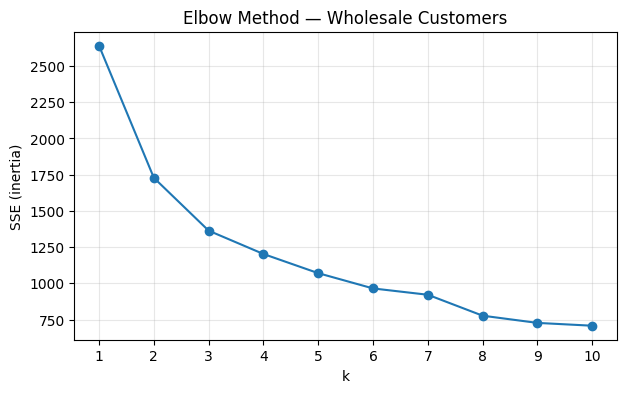

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(list(sse.keys()), list(sse.values()), marker="o")
plt.xlabel("k")
plt.ylabel("SSE (inertia)")
plt.title("Elbow Method — Wholesale Customers")
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.show()


## STEP 5 — Train K-Means (Reproduce Lesson)

In [12]:
kmeans = KMeans(n_clusters=K, n_init="auto", random_state=RANDOM_STATE)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels.astype(int)
print("=== SAMPLE WITH CLUSTERS ===")
print(df.head())


=== SAMPLE WITH CLUSTERS ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Cluster  
0     1338.00        0  
1     1776.00        0  
2     3938.25        0  
3     1788.00        3  
4     3938.25        3  


## STEP 6 — Evaluate K-Means

In [13]:
sil = silhouette_score(X_scaled, labels)
dbi = davies_bouldin_score(X_scaled, labels)
print("=== METRICS ===")
print(f"Silhouette Score : {sil:.3f} (closer to +1 is better)")
print(f"Davies–Bouldin   : {dbi:.3f} (lower is better)")


=== METRICS ===
Silhouette Score : 0.283 (closer to +1 is better)
Davies–Bouldin   : 1.270 (lower is better)


In [14]:
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers_original, columns=FEATURES)
centers_df.index.name = "Cluster"

print("=== CLUSTER CENTERS (Original Units) ===")
print(centers_df.round(2))


=== CLUSTER CENTERS (Original Units) ===
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0         9202.67   6833.30   9104.12  1326.16           3280.12     1871.76
1         8376.23   2150.65   3160.63  1646.33            779.25      674.02
2        17461.54  13805.60  17524.12  4120.57           5460.56     3583.64
3        22346.70   3409.14   3969.33  5819.60            583.07     1566.95
4         4916.98  10768.85  18350.13  1212.37           7780.02      981.37


## STEP 7 — Research & Train a Second Clustering Algorithm

**Algorithm chosen: Agglomerative (Hierarchical) Clustering.**

I chose Agglomerative Clustering because, unlike K-Means, it does not assume clusters are spherical or force a random centroid initialization — it builds clusters bottom-up by repeatedly merging the two closest points/clusters (using Ward linkage here, which minimizes within-cluster variance, making it a natural companion for comparison against K-Means's own variance-minimizing objective). This fits wholesale customer segmentation well because business spending patterns don't necessarily form neat round clusters — a dendrogram-based method can reveal nested sub-groups (e.g., a big "Horeca-like" group that further splits into small cafes vs. large hotels).

**Source:** scikit-learn documentation — `sklearn.cluster.AgglomerativeClustering` (https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)


In [15]:
from sklearn.cluster import AgglomerativeClustering

agglo = AgglomerativeClustering(n_clusters=K, linkage="ward")
labels_agglo = agglo.fit_predict(X_scaled)
df["Cluster_Agglo"] = labels_agglo.astype(int)

print("=== AGGLOMERATIVE CLUSTER SIZES ===")
print(df["Cluster_Agglo"].value_counts().sort_index())


=== AGGLOMERATIVE CLUSTER SIZES ===
Cluster_Agglo
0     70
1     72
2    164
3     55
4     79
Name: count, dtype: int64


## STEP 8 — Compare Methods

In [16]:
sil_agglo = silhouette_score(X_scaled, labels_agglo)

print("=== METHOD COMPARISON ===")
print(f"K-Means Silhouette Score        : {sil:.3f}")
print(f"Agglomerative Silhouette Score  : {sil_agglo:.3f}")

if sil > sil_agglo:
    print("\n>> K-Means produced better-separated clusters on this dataset.")
elif sil_agglo > sil:
    print("\n>> Agglomerative Clustering produced better-separated clusters on this dataset.")
else:
    print("\n>> Both methods produced equally separated clusters.")


=== METHOD COMPARISON ===
K-Means Silhouette Score        : 0.283
Agglomerative Silhouette Score  : 0.218

>> K-Means produced better-separated clusters on this dataset.


## STEP 9 — Sanity Check

In [17]:
sample_idx = [0, 1, 2]
sanity = df.loc[sample_idx, ["Channel", "Region"] + FEATURES + ["Cluster", "Cluster_Agglo"]]
print("=== SANITY CHECK (3 Clients) ===")
print(sanity)


=== SANITY CHECK (3 Clients) ===
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   

   Delicassen  Cluster  Cluster_Agglo  
0     1338.00        0              4  
1     1776.00        0              4  
2     3938.25        0              0  


## STEP 10 — Save Output

In [18]:
save_df = df.drop(columns=["Cluster_Agglo"])
save_df.to_csv(OUT_PATH, index=False)
print(f"Saved clustered dataset → {OUT_PATH}")
save_df.head()


Saved clustered dataset → segmented_wholesale_customers.csv


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669.0,9656.0,7561.0,214.0,2674.0,1338.00,0
1,2,3,7057.0,9810.0,9568.0,1762.0,3293.0,1776.00,0
2,2,3,6353.0,8808.0,7684.0,2405.0,3516.0,3938.25,0
3,1,3,13265.0,1196.0,4221.0,6404.0,507.0,1788.00,3
4,2,3,22615.0,5410.0,7198.0,3915.0,1777.0,3938.25,3
